[Sascha Spors](https://orcid.org/0000-0001-7225-9992),
Professorship Signal Theory and Digital Signal Processing,
[Institute of Communications Engineering (INT)](https://www.int.uni-rostock.de/),
Faculty of Computer Science and Electrical Engineering (IEF),
[University of Rostock, Germany](https://www.uni-rostock.de/en/)

# Tutorial Signals and Systems (Signal- und Systemtheorie)

Summer Semester 2021 (Bachelor Course #24015)

- lecture: https://github.com/spatialaudio/signals-and-systems-lecture
- tutorial: https://github.com/spatialaudio/signals-and-systems-exercises

WIP...
The project is currently under heavy development while adding new material for the summer semester 2021

Feel free to contact lecturer [frank.schultz@uni-rostock.de](https://orcid.org/0000-0002-3010-0294)

## Übung / Exercise 4

# Spectrum from Rect Cosine

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def my_sinc(x):  # we rather use definition sinc(x) = sin(x)/x, thus:
    return np.sinc(x/np.pi)

In [2]:
def plot_rect_cos(T):
    # rect(t/T) o-o T sinc(wT/2)
    t = np.linspace(-T/2, +T/2, 2**11)
    w = np.linspace(-6, 6, 2**11)

    A1 = 1
    w1 = 1

    A2 = 3/2
    w2 = 3/2

    A3 = 2
    w3 = 2

    x = A1*np.cos(w1*t) + A2*np.cos(w2*t) + A3*np.cos(w3*t)

    X1p = 1/(2*np.pi) * (A1*np.pi) * T*my_sinc((w-w1)*T/2)
    X1n = 1/(2*np.pi) * (A1*np.pi) * T*my_sinc((w+w1)*T/2)

    X2p = 1/(2*np.pi) * (A2*np.pi) * T*my_sinc((w-w2)*T/2)
    X2n = 1/(2*np.pi) * (A2*np.pi) * T*my_sinc((w+w2)*T/2)

    X3p = 1/(2*np.pi) * (A3*np.pi) * T*my_sinc((w-w3)*T/2)
    X3n = 1/(2*np.pi) * (A3*np.pi) * T*my_sinc((w+w3)*T/2)

    plt.figure(figsize=(10, 10))
    plt.subplot(3, 1, 1)
    plt.plot(t, x, 'C0', lw=3)
    plt.plot([-np.ceil(T/2), -T/2], [0, 0], 'C0', lw=3)
    plt.plot([T/2, np.ceil(T/2)], [0, 0], 'C0', lw=3)
    plt.xlabel(r'$t$ / s')
    plt.ylabel('$x(t)$')
    plt.xlim(-np.ceil(T/2), +np.ceil(T/2))
    plt.grid(True)

    plt.subplot(3, 1, 2)
    head_length = 0.25
    plt.arrow(+w1, 0, 0, A1*np.pi-head_length, color='C0',
              width=0.05, head_length=head_length)
    plt.arrow(+w2, 0, 0, A2*np.pi-head_length, color='C1',
              width=0.05, head_length=head_length)
    plt.arrow(+w3, 0, 0, A3*np.pi-head_length, color='C2',
              width=0.05, head_length=head_length)

    plt.arrow(-w1, 0, 0, A1*np.pi-head_length, color='C3',
              width=0.05, head_length=head_length)
    plt.arrow(-w2, 0, 0, A2*np.pi-head_length, color='C4',
              width=0.05, head_length=head_length)
    plt.arrow(-w3, 0, 0, A3*np.pi-head_length, color='C5',
              width=0.05, head_length=head_length)

    plt.plot(w, X1p+X1n + X2p+X2n + X3p+X3n, 'k')

    plt.xlabel(r'$\omega$ / (rad/s)')
    plt.ylabel('$X(\mathrm{j}\omega)$')
    plt.xticks(np.arange(-6, 7))
    plt.xlim(-6, 6)
    plt.grid(True)

    plt.subplot(3, 1, 3)
    plt.plot(
        w, X1p, label=r'$\frac{A_1 \pi}{2\pi}\delta(\omega-\omega_1)\ast T \mathrm{sinc}(\frac{\omega T}{2})$')
    plt.plot(
        w, X2p, label=r'$\frac{A_2 \pi}{2\pi}\delta(\omega-\omega_2)\ast T \mathrm{sinc}(\frac{\omega T}{2})$')
    plt.plot(
        w, X3p, label=r'$\frac{A_3 \pi}{2\pi}\delta(\omega-\omega_3)\ast T \mathrm{sinc}(\frac{\omega T}{2})$')
    plt.plot(
        w, X1n, label=r'$\frac{A_1 \pi}{2\pi}\delta(\omega+\omega_1)\ast T \mathrm{sinc}(\frac{\omega T}{2})$')
    plt.plot(
        w, X2n, label=r'$\frac{A_2 \pi}{2\pi}\delta(\omega+\omega_2)\ast T \mathrm{sinc}(\frac{\omega T}{2})$')
    plt.plot(
        w, X3n, label=r'$\frac{A_3 \pi}{2\pi}\delta(\omega+\omega_3)\ast T \mathrm{sinc}(\frac{\omega T}{2})$')
    plt.xlabel(r'$\omega$ / (rad/s)')
    plt.xticks(np.arange(-6, 7))
    plt.xlim(-6, 6)
    plt.legend()
    plt.grid(True)

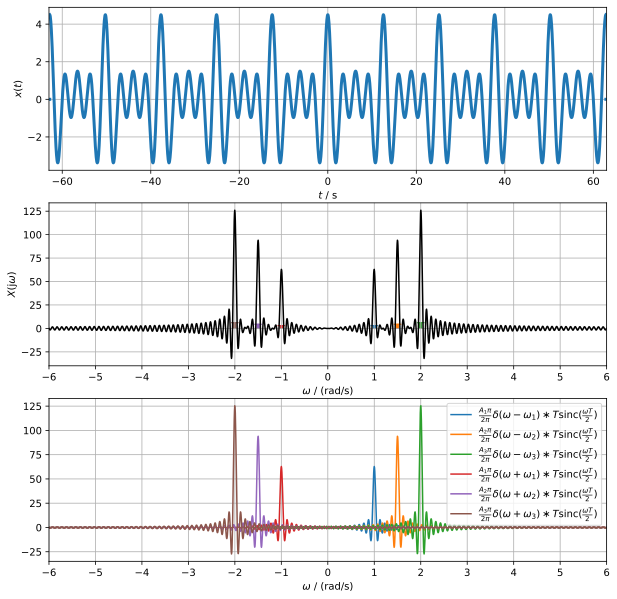

In [3]:
T = 2*np.pi*20
plot_rect_cos(T)

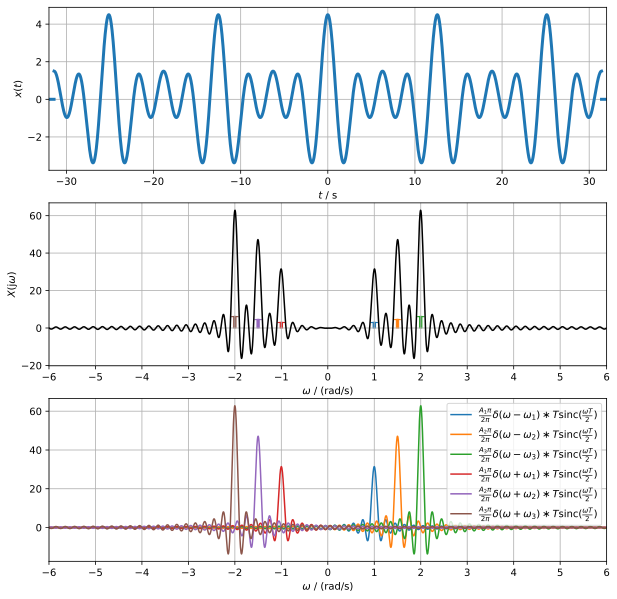

In [4]:
T = 2*np.pi*10
plot_rect_cos(T)

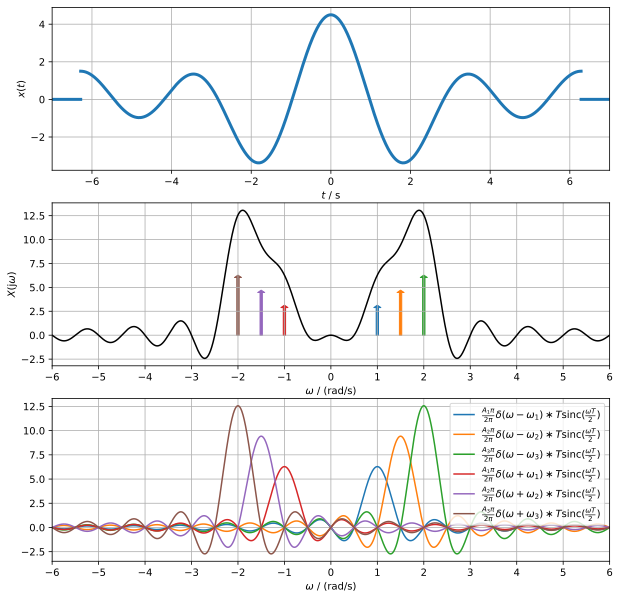

In [5]:
T = 2*np.pi*2
plot_rect_cos(T)

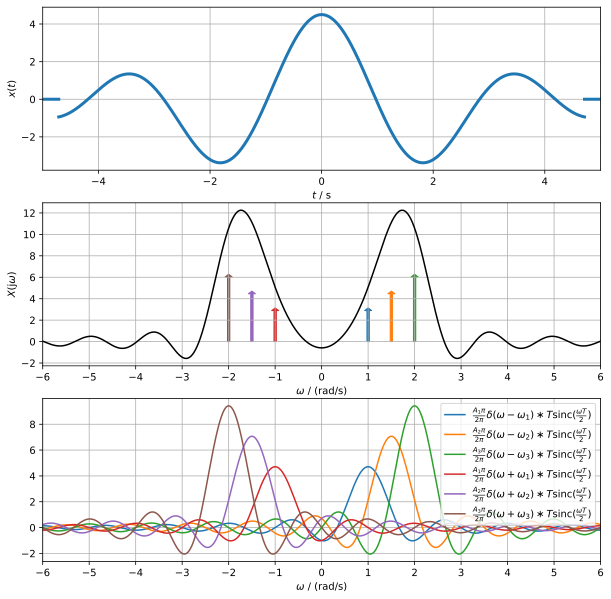

In [6]:
T = 2*np.pi*1.5
plot_rect_cos(T)

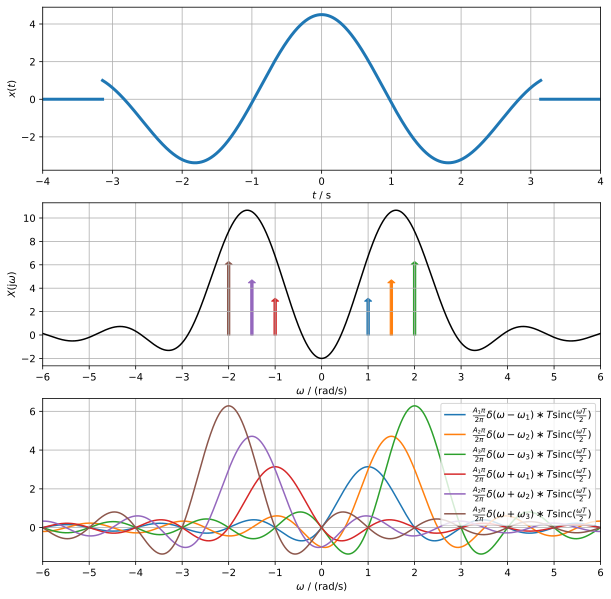

In [7]:
T = 2*np.pi*1
plot_rect_cos(T)

3.2


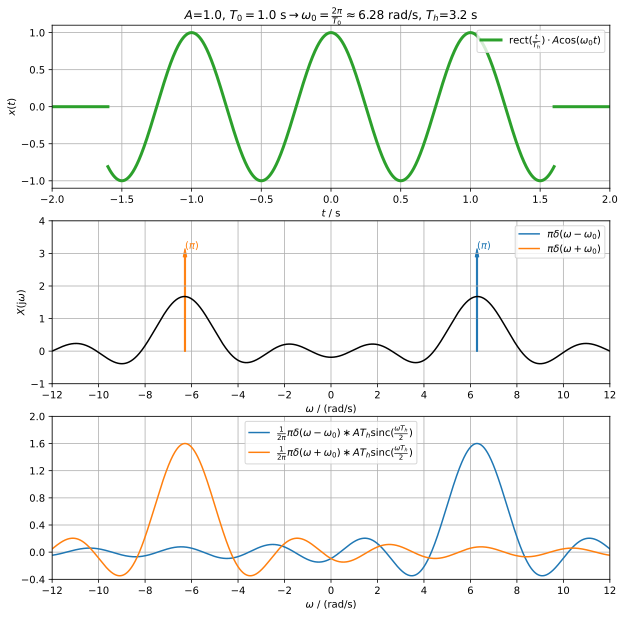

In [8]:
A = 1
T0 = 1
w0 = 2*np.pi/T0

Th = 4.8/1.5*T0
Th = 3.2
print(Th)

# rect(t/T) o-o T sinc(wT/2)
t = np.linspace(-Th/2, +Th/2, 2**11)
w = np.linspace(-2*w0, +2*w0, 2**11)

x = A*np.cos(w0*t)

X1p = 1/(2*np.pi) * (A*np.pi) * Th*my_sinc((w-w0)*Th/2)
X1n = 1/(2*np.pi) * (A*np.pi) * Th*my_sinc((w+w0)*Th/2)

plt.figure(figsize=(10, 10))
plt.subplot(3, 1, 1)
plt.plot(t, x, 'C2', lw=3,
         label=r'$\mathrm{rect}(\frac{t}{T_h})\cdot A \cos(\omega_0 t)$')
plt.plot([-np.ceil(Th/2), -Th/2], [0, 0], 'C2', lw=3)
plt.plot([Th/2, np.ceil(Th/2)], [0, 0], 'C2', lw=3)
plt.xlabel(r'$t$ / s')
plt.ylabel('$x(t)$')
plt.title(
    r'$A$=%1.1f, $T_0=$%1.1f s$\rightarrow\omega_0 = \frac{2\pi}{T_0}\approx$%2.2f rad/s, $T_h$=%1.1f s' % (A, T0, w0, Th))
plt.xlim(-np.ceil(Th/2), +np.ceil(Th/2))
plt.legend(loc='upper right')
plt.grid(True)

plt.subplot(3, 1, 2)
head_length = 0.25

plt.plot([w0, w0], [0, 1], 'C0', label=r'$\pi\delta(\omega-\omega_0)$')
plt.plot([-w0, -w0], [0, 1], 'C1', label=r'$\pi\delta(\omega+\omega_0)$')

plt.arrow(+w0, 0, 0, A*np.pi-head_length, color='C0',
          width=0.05, head_length=head_length)

plt.arrow(-w0, 0, 0, A*np.pi-head_length, color='C1',
          width=0.05, head_length=head_length)

plt.plot(w, X1p+X1n, 'k')

plt.text(-w0, np.pi, r'$(\pi)$', color='C1')
plt.text(+w0, np.pi, r'$(\pi)$', color='C0')

plt.xlabel(r'$\omega$ / (rad/s)')
plt.ylabel('$X(\mathrm{j}\omega)$')
if T0 == 1:
    plt.xticks(np.arange(-12, 14, 2))
    plt.xlim(-12, 12)
if Th == 3.2 and A == 1:
    plt.ylim(-1, 4)
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(
    w, X1p, label=r'$\frac{1}{2\pi}\pi\delta(\omega-\omega_0)\ast A T_h \mathrm{sinc}(\frac{\omega T_h}{2})$')
plt.plot(
    w, X1n, label=r'$\frac{1}{2\pi}\pi\delta(\omega+\omega_0)\ast A T_h \mathrm{sinc}(\frac{\omega T_h}{2})$')
plt.xlabel(r'$\omega$ / (rad/s)')
if T0 == 1:
    plt.xticks(np.arange(-12, 14, 2))
    plt.xlim(-12, 12)
if Th == 3.2 and A == 1:
    plt.yticks(np.arange(-0.4, 2.4, 0.4))
    plt.ylim(-0.4, 2)
plt.legend()
plt.grid(True)
plt.savefig('rect_cos_610482EF57_1.pdf')

3.2


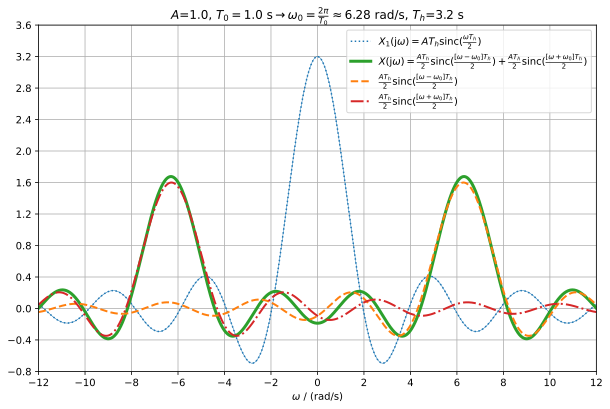

In [9]:
A = 1
T0 = 1
w0 = 2*np.pi/T0

Th = 4.8/1.5*T0
Th = 3.2
print(Th)

# rect(t/T) o-o T sinc(wT/2)
w = np.linspace(-2*w0, +2*w0, 2**11)

Xrect = A*Th * my_sinc(w*Th/2)
Xmodp = A*Th/2*my_sinc((w-w0)*Th/2)
Xmodn = A*Th/2*my_sinc((w+w0)*Th/2)

plt.figure(figsize=(10, 10*10/16))
plt.plot(
    w, Xrect, 'C0', lw=0.5)
plt.plot(
    w, Xrect, 'C0:', label=r'$X_1(\mathrm{j}\omega) = A T_h \mathrm{sinc}(\frac{\omega T_h}{2})$')
plt.plot(
    w, Xmodp+Xmodn, 'C2', lw=3, label=r'$X(\mathrm{j}\omega) = \frac{A T_h}{2} \mathrm{sinc}(\frac{[\omega-\omega_0] T_h}{2})+\frac{A T_h}{2} \mathrm{sinc}(\frac{[\omega+\omega_0] T_h}{2})$')
plt.plot(
    w, Xmodp, 'C1--', lw=2, label=r'$\frac{A T_h}{2} \mathrm{sinc}(\frac{[\omega-\omega_0] T_h}{2})$')
plt.plot(
    w, Xmodn, 'C3-.', lw=2, label=r'$\frac{A T_h}{2} \mathrm{sinc}(\frac{[\omega+\omega_0] T_h}{2})$')
plt.xlabel(r'$\omega$ / (rad/s)')
plt.title(
    r'$A$=%1.1f, $T_0=$%1.1f s$\rightarrow\omega_0 = \frac{2\pi}{T_0}\approx$%2.2f rad/s, $T_h$=%1.1f s' % (A, T0, w0, Th))
plt.xticks(np.arange(-12, 14, 2))
plt.xlim(-12, 12)
plt.yticks(np.arange(-0.8, 4, 0.4))
plt.ylim(-0.8, 3.6)
plt.legend()
plt.grid(True)
plt.savefig('rect_cos_610482EF57_2.pdf')

## Copyright

This tutorial is provided as Open Educational Resource (OER), to be found at
https://github.com/spatialaudio/signals-and-systems-exercises
accompanying the OER lecture
https://github.com/spatialaudio/signals-and-systems-lecture.
Both are licensed under a) the Creative Commons Attribution 4.0 International
License for text and graphics and b) the MIT License for source code.
Please attribute material from the tutorial as *Frank Schultz,
Continuous- and Discrete-Time Signals and Systems - A Tutorial Featuring
Computational Examples, University of Rostock* with
``main file, github URL, commit number and/or version tag, year``.